In [1]:
import networkx as nx
import networkit as nk
import rustworkx as rx
import igraph as ig

import osmnx as ox
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.animation import FuncAnimation
import itertools as it
from tqdm import tqdm
import logging
from collections import OrderedDict
import operator
import shapely
from shapely.geometry import LineString, Point
import shapely.geometry
from shapely.ops import linemerge
import pandas as pd
import copy
import datetime
import geopandas as gpd
import movingpandas as mpd

import sys
from pathlib import Path

#Truc moche pour que les imports de src marchent
current_file = Path.cwd()
project_root = current_file.parents[0]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from src.main_helpers import timeit, Base_car_fleet, Car, Display, UnitTest, select_min_weight_lane
from src.attack.attack import feature_based_attack

np.random.seed(1)

ox.__version__

/home/lucas/.pyenv/versions/sim/lib/python3.12/site-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)


'2.1.0'

### Initial state

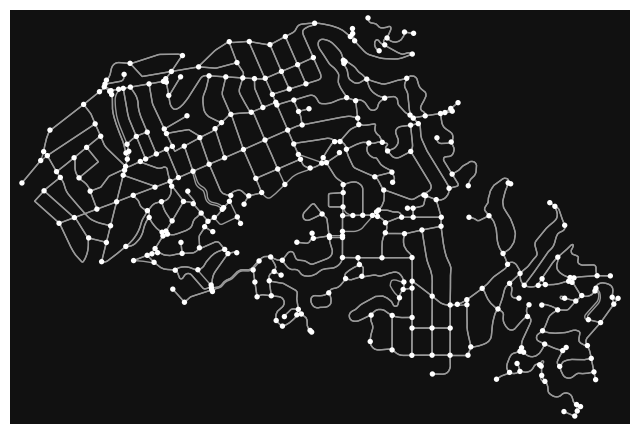

In [2]:
# download/model a street network for some city then visualize it
# G = ox.graph.graph_from_place("Escaudes, France", network_type="drive")
G = ox.graph.graph_from_place("Piedmont, California, USA", network_type="drive")
fig, ax = ox.plot.plot_graph(G)

### Preprocessing

In [3]:
for u,v,k in G.edges:
    attrs_e = {(u, v, k): {
        'load': 0, 
        'weight': 1, 
        'capacity': np.random.randint(5,10)
        # 'capacity': 1

        }
    }
    nx.set_edge_attributes(G, attrs_e)

for u,v,k in G.edges:
    print(G[u][v][k])
    break

{'osmid': 6345781, 'highway': 'residential', 'name': 'Rose Avenue', 'oneway': False, 'reversed': False, 'length': np.float64(230.12441194959652), 'geometry': <LINESTRING (-122.248 37.826, -122.248 37.826, -122.246 37.828)>, 'load': 0, 'weight': 1, 'capacity': 8}


In [4]:
for u,v,k in G.edges:
    if 'geometry' not in G.edges[u,v,k]:
        G[u][v][k]['geometry']=LineString([[G.nodes[u]['x'], G.nodes[u]['y']], [G.nodes[v]['x'], G.nodes[v]['y']]])

In [5]:
# G3=ox.convert.to_digraph(G) NOT FOR NOW CAUSE WE SET WEIGHTS=1 or 10000
# G3=nx.DiGraph(G)
G3=G

In [6]:
len(max(list(nx.strongly_connected_components(G3)), key=len))/G3.number_of_nodes()

0.9914772727272727

In [7]:
# Get strongly connected component
G4 = max(list(nx.strongly_connected_components(G3)), key=len)
G4 = G3.subgraph(G4)

In [8]:
G4_proj=ox.project_graph(G4)

### Bla

In [ ]:
class Car_fleet(Base_car_fleet):

    def move(self, car: Car, time_step: float = 20):
        """
    Moves a car along its path for a given time step.
    Handles edge transitions, interaction updates (load increments/decrements),
    and path completion.
        """
        time_remaining = time_step
        speed = 50 / 3.6  # m/s

        while time_remaining > 0 :

            # Si l'arête E_k sur laquelle t'étais censée passer existe plus, arrête toi
            if not self.rx_helper.nx_graph.has_edge(car.last_true_node, car.next_true_node, car.next_edge_key):
                break

            edge = self.rx_helper.nx_graph[car.last_true_node][car.next_true_node][car.next_edge_key]
            geom: LineString = edge['geometry']
            
            dist_from_start = geom.project(car.loc)
            dist_to_go = speed * time_remaining
            new_dist = dist_from_start + dist_to_go

            # Si tu vas aller plus loin que le prochain noeud
            if new_dist >= geom.length:
                time_used = (geom.length - dist_from_start) / speed
                time_remaining -= time_used

                # Si tu sais où aller après le prochain noeud, check quelle arête E_k+1 tu vas prendre
                if len(car.path)>1: 
                    next_edge_key, _ = select_min_weight_lane(
                                self.rx_helper.nx_graph, car.next_true_node, car.path[1], 'weight' 
                            )
                    
                # Si ton prochain noeud c'est l'arrivée, y a pas de prochaine arête, vas-y
                elif car.next_true_node==car.arr: 
                    if not car.first_step:
                        self.handle_interactions(car.last_true_node, car.next_true_node,
                            car.next_edge_key, -1, 1, op=operator.lt)
                    car.go_to_next_true_node(self.rx_helper.nx_graph)
                    car.log_traj(self.log_trajs, self.clock+datetime.timedelta(seconds=time_step-time_remaining))
                    break

                # Si l'arête E_k+1 n'existe pas car bloquée, arrête toi au bout de la route
                else:
                    car.loc = geom.interpolate(geom.length)
                    car.log_traj(self.log_trajs, self.clock+datetime.timedelta(seconds=time_step-time_remaining))
                    break

                if not car.first_step:
                    car.first_step=self.handle_interactions(car.last_true_node, car.next_true_node,
                                            car.next_edge_key, -1, 1, op=operator.lt)
                
                road = car.go_to_next_true_node(self.rx_helper.nx_graph)
                car.log_traj(self.log_trajs, self.clock+datetime.timedelta(seconds=time_step-time_remaining))
                car.first_step=False
                

                
                car.next_edge_key = next_edge_key
                self.handle_interactions(car.last_true_node, car.next_true_node,
                                        car.next_edge_key, 1, 10000, op=operator.ge)
            # Si tu vas pas plus loin que le prochain noeud, avance sur l'arête E_k
            else:
                if car.first_step:
                    car.first_step=self.handle_interactions(car.last_true_node, car.next_true_node, car.next_edge_key, 1, 10000, op=operator.ge)
                car.loc = geom.interpolate(new_dist)
                car.log_traj(self.log_trajs, self.clock+datetime.timedelta(seconds=time_step-time_remaining))
                time_remaining = 0

        return car.loc
    
    @timeit
    def update_fleet(self, time_step):
        """
    Updates car states and handles interactions during displacement.
        """
        for car in self.get_fleet(include_completed=False):
            car.reset_traj()
            # On recalcule pas le chemin à un pas de l'arrivée si on sait où on va
            if car.next_true_node!=car.arr:
                path = copy.deepcopy(self.all_paths[car.next_true_node][car.arr][0])
                car.path=path
                car.cost=self.get_cost(path, 'weight')
                self.log_info(car)
            
            # Bouge
            point=self.move(car, time_step)

            # On supprime pas l'ancien état puisque deux voitures peuvent se suivre
            self.edges_state[(car.next_true_node, car.arr)]=self.check_edges_along_path(car.path)

    def run(self, attack=True, repair=True, time_step=20):
        self.info=[]
        if not self.all_completed():
            if attack :
                self.launch_attack()
            if repair :
                self.repair_attack()
            all_paths=self.calculate_paths(dist=3)
            self.update_fleet(time_step)
            self.step+=1
            self.clock+=datetime.timedelta(seconds=time_step)
            self.trajs = pd.concat([self.trajs, self.format_trajs_step()]).pipe(gpd.GeoDataFrame)


### Dynamique induite et update

 99%|█████████▉| 89/90 [00:04<00:00, 28.06it/s]

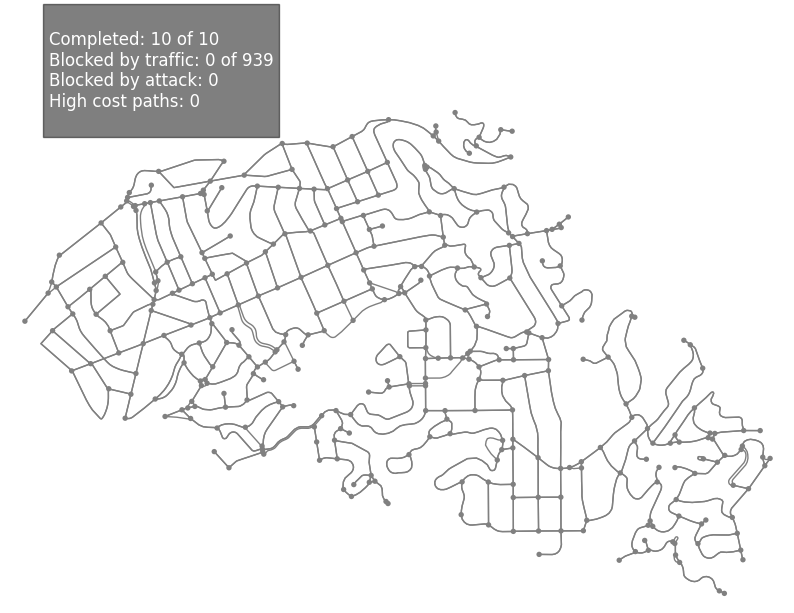

91it [00:09,  9.68it/s]                        


In [48]:
demand=Car_fleet(G4_proj.copy(), size=10, log_trajs=10)
demand.prepare_attack(attack='deg', batch_size=10, number_steps=30)
frames=90
logging.info(f'_'*30)

def update(frame):
    pbar.update(1)
    if demand.all_completed():
        return ax,
    
    ax.clear()
    if frame > 0:
        demand.run(attack=False, repair=False, time_step=20)
    # demand.display_h.display_huge(demand, ax=ax)
    demand.display_h.display(demand, ax=ax)
    # demand.display_h.display_graph(demand.rx_helper.nx_graph, demand)
    string=f'''
Completed: {sum(demand.get_completed())} of {len(demand.fleet)}
Blocked by traffic: {sum(demand.get_edge_blocked().values())} of {demand.graph.number_of_edges()}
Blocked by attack: {len(list(it.chain.from_iterable(demand.rmvd_edges)))}
High cost paths: {len(demand.info)}
'''
    ax.text(0.05, 0.95, string,
            transform=ax.transAxes, fontsize=12, color='white', 
            bbox=dict(facecolor='black', alpha=0.5))
    return ax,

with tqdm(total=frames) as pbar:
    fig, ax = plt.subplots(figsize=(10, 8))
    ani = FuncAnimation(fig, update, frames=frames, interval=150, repeat=False)
    ani.save("ani.gif", writer='pillow', 
            #  progress_callback = lambda i, n: print(f'Saving frame {i}/{n}', end='\r')
             )
    plt.show()
UnitTest(demand).run()

### Viz

In [11]:
demand.save_trajs('tmp.gpkg')

In [ ]:
dis=Display()

m=dis.display_graph(demand.graph, demand, False, None)
# m=dis.display_graph(demand.graph, None, False, None)

tc = mpd.TrajectoryCollection(dis.transform_df(demand.trajs), "trajectory_id", t="t")
m=tc.explore(column="trajectory_id", cmap=dis.colors[:demand.log_trajs], style_kwds={"weight": 4}, m=m)
dis.show_folium_safe(m)

In [13]:
dis=Display()
m=dis.highlight_node(demand.rx_helper.nx_graph, 245384115, markers=[Point(568399.562347318, 4185934.875910906),Point(568345.8942650286, 4186300.3485423014)])